# Модель детекции шаринга учётных записей Альфа-Бизнеса

Альфа-Бизнес — интернет-банк для корпоративных клиентов (3.5 млн компаний, 5.2 млн учётных записей). Предполагаемая доля аккаунтов с шарингом — **20%** (более 1 млн УЗ).

Модель классифицирует каждую сессию по трём сценариям:

|Класс|Описание|Типичный профиль|
|---|---|---|
|**0 — Норма**|Владелец аккаунта|Стабильное устройство, привычное время, знакомый IP|
|**1 — Доверенный шаринг**|Бухгалтер/ассистент с переданными кредами|Другое устройство, другой навигационный паттерн, высокая энтропия|
|**2 — Компрометация**|Несанкционированный доступ|Новый IP из другого региона, быстрый переход к платежам, новые контрагенты|


## Скрипт формирования синтетического датасета

In [11]:
import pandas as pd
import numpy as np

# Настройки генерации
N_SAMPLES = 1000
np.random.seed(42)

def generate_final_dataset(n_samples):
    data = []

    # Справочники для категориальных признаков
    os_browsers = ['Windows/Chrome', 'Windows/Firefox', 'macOS/Safari', 'iOS/App', 'Android/App']

    for i in range(n_samples):
        # Определение класса: 0-Норма, 1-Шаринг, 2-Компрометация
        cls = np.random.choice([0, 1, 2], p=[0.70, 0.20, 0.10])

        # Контекст: Налоговый период (20-28 числа)
        is_tax_period = np.random.choice([0, 1], p=[0.75, 0.25])

        # --- 1. ТЕХНИЧЕСКИЙ БЛОК (Т) ---
        if cls == 0:
            is_traveling = np.random.choice([0, 1], p=[0.9, 0.1])
            device_match = 1 if not is_traveling else 0
            geo_vel = np.random.uniform(0, 400) if is_traveling else 0
            ip_new = 1 if is_traveling else 0
            unique_devs = np.random.randint(1, 3)
        elif cls == 1:
            device_match = 0
            geo_vel = 0 # Обычно бухгалтер в том же городе
            ip_new = np.random.choice([0, 1], p=[0.7, 0.3])
            unique_devs = np.random.randint(2, 4)
        else: # cls == 2
            device_match = 0
            geo_vel = np.random.uniform(600, 1500) # VPN или прыжок
            ip_new = 1
            unique_devs = np.random.randint(3, 6)

        # --- 2. ПОВЕДЕНЧЕСКИЙ БЛОК (П) ---
        if cls == 0:
            entropy = np.random.uniform(1.0, 1.6)
            alien_idx = np.random.uniform(0.0, 0.3)
            start_std = np.random.uniform(1800, 5400) # Хаотичное время входа
        elif cls == 1:
            entropy = np.random.uniform(1.8, 2.6) # Бухгалтер смотрит много разделов
            alien_idx = np.random.uniform(0.7, 1.0) # Сразу в выписки/реестры
            start_std = np.random.uniform(300, 900) # Строго рабочий график
        else: # cls == 2
            entropy = np.random.uniform(0.2, 0.6) # Узкий фокус на кражу
            alien_idx = np.random.uniform(0.0, 0.2)
            start_std = np.random.uniform(10, 300)

        # --- 3. ОПЕРАЦИОННЫЙ БЛОК (О) ---
        tax_multiplier = 1.5 if is_tax_period else 1.0
        if cls == 0:
            s_ratio = np.random.uniform(0.7, 1.0)
            time_delta = np.random.uniform(30, 600)
            new_cp_ratio = np.random.uniform(0.0, 0.15)
        elif cls == 1:
            s_ratio = np.random.uniform(0.0, 0.2) # Бухгалтер не подписывает
            time_delta = np.random.uniform(3600, 20000) # Директор подпишет позже
            new_cp_ratio = np.random.uniform(0.1, 0.3) * tax_multiplier
        else: # cls == 2
            s_ratio = np.random.uniform(0.9, 1.0) # Взломщик подписывает всё сам
            time_delta = np.random.uniform(1, 40) # Очень быстро
            new_cp_ratio = np.random.uniform(0.7, 1.0) # Новые счета для вывода

        # --- 4. МЕТРИКИ ОТКЛОНЕНИЯ (BASELINE) ---
        # Вычисляем косинусное расстояние от исторического профиля
        if cls == 0:
            vector_dist = np.random.uniform(0.02, 0.18)
            cluster_shift = np.random.uniform(0.01, 0.12)
        elif cls == 1:
            vector_dist = np.random.uniform(0.45, 0.68)
            cluster_shift = np.random.uniform(0.40, 0.75)
        else: # cls == 2
            vector_dist = np.random.uniform(0.75, 0.98)
            cluster_shift = np.random.uniform(0.80, 1.0)

        data.append({
            'is_tax_period': is_tax_period,
            'device_fingerprint_match': device_match,
            'os_browser_combo': np.random.choice(os_browsers),
            'ip_new_for_account': ip_new,
            'geo_velocity_kmh': geo_vel,
            'unique_devices_30d': unique_devs,
            'concurrent_sessions': 1 if (cls == 1 and np.random.rand() > 0.5) else 0,
            'session_start_std_dev': start_std,
            'section_entropy': entropy,
            'professional_alien_index': alien_idx,
            'sign_ratio': s_ratio,
            'draft_to_sign_time_delta': time_delta,
            'new_counterparty_volume_ratio': new_cp_ratio,
            'behavior_cluster_shift': cluster_shift,
            'vector_cosine_dist': vector_dist,
            'is_sharing_detected': cls
        })

    return pd.DataFrame(data)

df = generate_final_dataset(N_SAMPLES)
df.to_excel("../data/alfa_business_comprehensive_dataset.xlsx", index=False)
print("Датасет сгенерирован и сохранен в файл.")

Датасет сгенерирован и сохранен в файл.


# Модель

### Параметры среды и импорты

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             accuracy_score, roc_curve, auc, precision_recall_curve,
                             f1_score, precision_score, recall_score)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

CLASS_NAMES = {0: 'Норма\n(Владелец)', 1: 'Доверенный\nшаринг', 2: 'Компро-\nметация'}
CLASS_NAMES_SHORT = {0: 'Норма', 1: 'Шаринг', 2: 'Компрометация'}
COLORS3 = ['#2ecc71', '#f39c12', '#e74c3c']
ALFA_RED = '#EF3124'

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10,
    'figure.facecolor': 'white'
})

### Загрузка данных

In [13]:
df = pd.read_excel('../data/alfa_business_noisy_dataset.xlsx')

print(f'''Размер: {df.shape})
Распределение классов:
{df['is_sharing_detected'].value_counts().sort_index()}
Пропуски: {df.isnull().sum().sum()}
Типы данных:\n{df.dtypes}''')

df.head()

Размер: (1000, 16))
Распределение классов:
is_sharing_detected
0    666
1    232
2    102
Name: count, dtype: int64
Пропуски: 0
Типы данных:
is_tax_period                      int64
device_fingerprint_match           int64
os_browser_combo                  object
ip_new_for_account                 int64
geo_velocity_kmh                 float64
unique_devices_30d                 int64
concurrent_sessions                int64
session_start_std_dev            float64
section_entropy                  float64
professional_alien_index         float64
sign_ratio                       float64
draft_to_sign_time_delta         float64
new_counterparty_volume_ratio    float64
behavior_cluster_shift           float64
vector_cosine_dist               float64
is_sharing_detected                int64
dtype: object


,is_tax_period,device_fingerprint_match,os_browser_combo,ip_new_for_account,geo_velocity_kmh,unique_devices_30d,concurrent_sessions,session_start_std_dev,section_entropy,professional_alien_index,sign_ratio,draft_to_sign_time_delta,new_counterparty_volume_ratio,behavior_cluster_shift,vector_cosine_dist,is_sharing_detected
0,1,1,iOS/App,0,0.000000,2,0,3442.015800,1.482955,0.263529,1.000000,857.399547,0.055271,0.321625,0.224400,0
1,0,0,macOS/Safari,1,61.294915,3,0,10.000000,0.050000,0.029023,1.000000,161.677877,0.770458,0.698346,0.987514,2
2,1,1,iOS/App,0,0.000000,1,0,2613.795789,1.266984,0.000000,1.000000,1166.494460,0.085703,0.000000,0.000000,0
3,0,1,Windows/Firefox,0,0.000000,1,0,3879.649680,0.220924,0.799705,0.912636,0.500000,0.000000,0.311755,0.160326,0
4,1,1,Windows/Firefox,1,0.000000,3,0,655.326251,1.851510,0.694639,0.000000,22047.292419,0.568700,0.389025,0.711331,1


### EDA

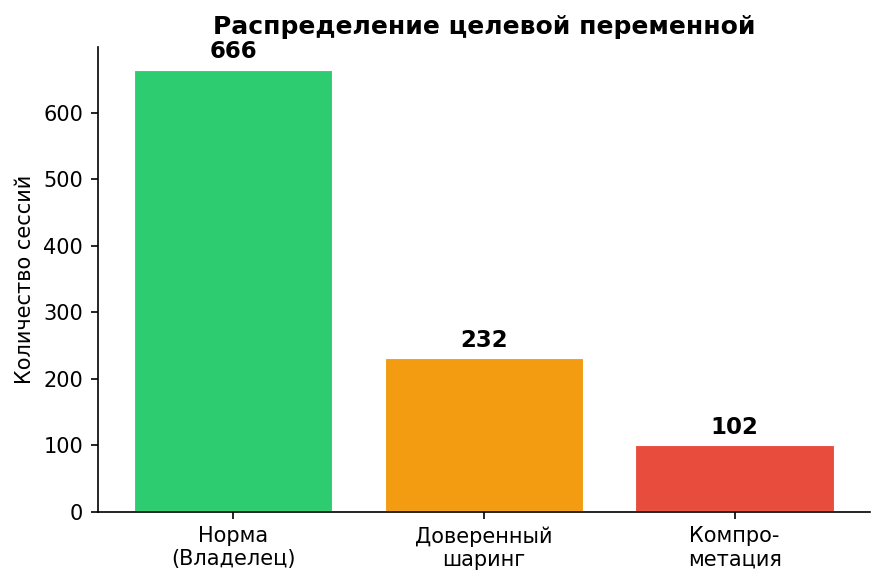

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['is_sharing_detected'].value_counts().sort_index()
bars = ax.bar([CLASS_NAMES[i] for i in counts.index], counts.values,
              color=COLORS3, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('Количество сессий')
ax.set_title('Распределение целевой переменной', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('01_target_distribution.png')
plt.show()

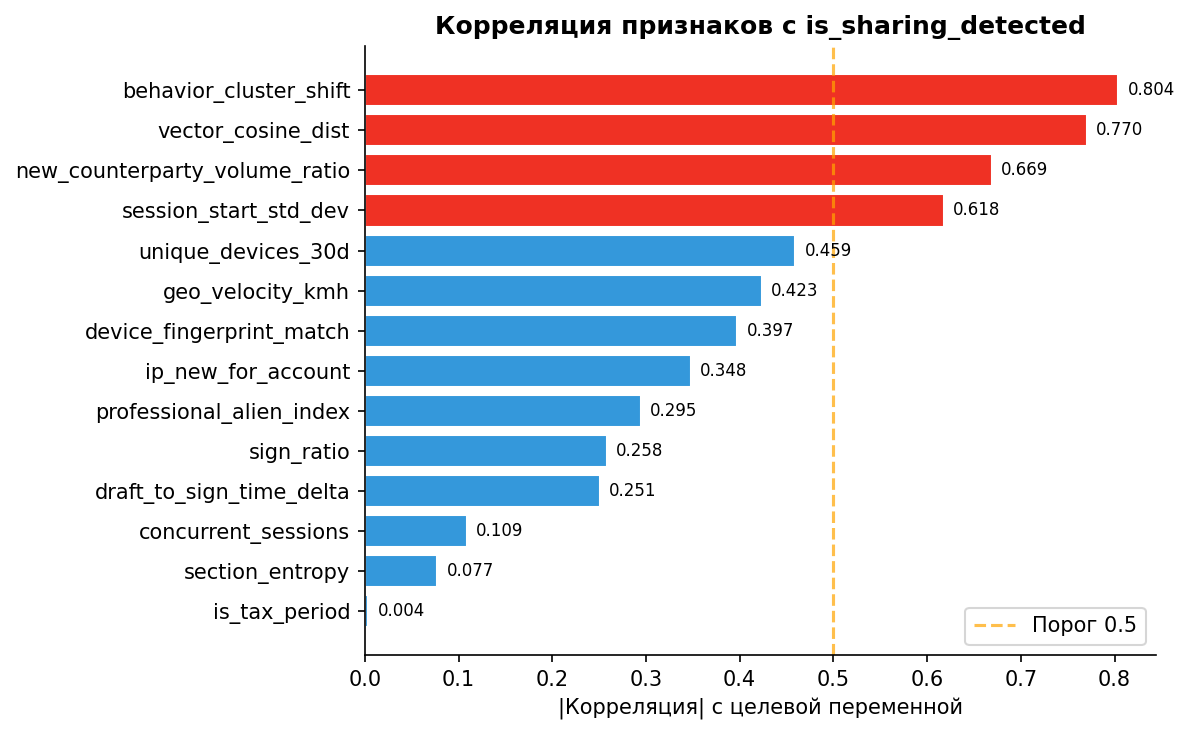

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('is_sharing_detected')
corrs = df[numeric_cols].corrwith(df['is_sharing_detected']).abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_corr = [ALFA_RED if v > 0.5 else '#3498db' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors_corr, edgecolor='white')
ax.axvline(0.5, color='orange', linestyle='--', alpha=0.7, label='Порог 0.5')
for i, (name, val) in enumerate(zip(corrs.index, corrs.values)):
    ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=8)
ax.set_xlabel('|Корреляция| с целевой переменной')
ax.set_title('Корреляция признаков с is_sharing_detected', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('02_feature_correlations.png')
plt.show()

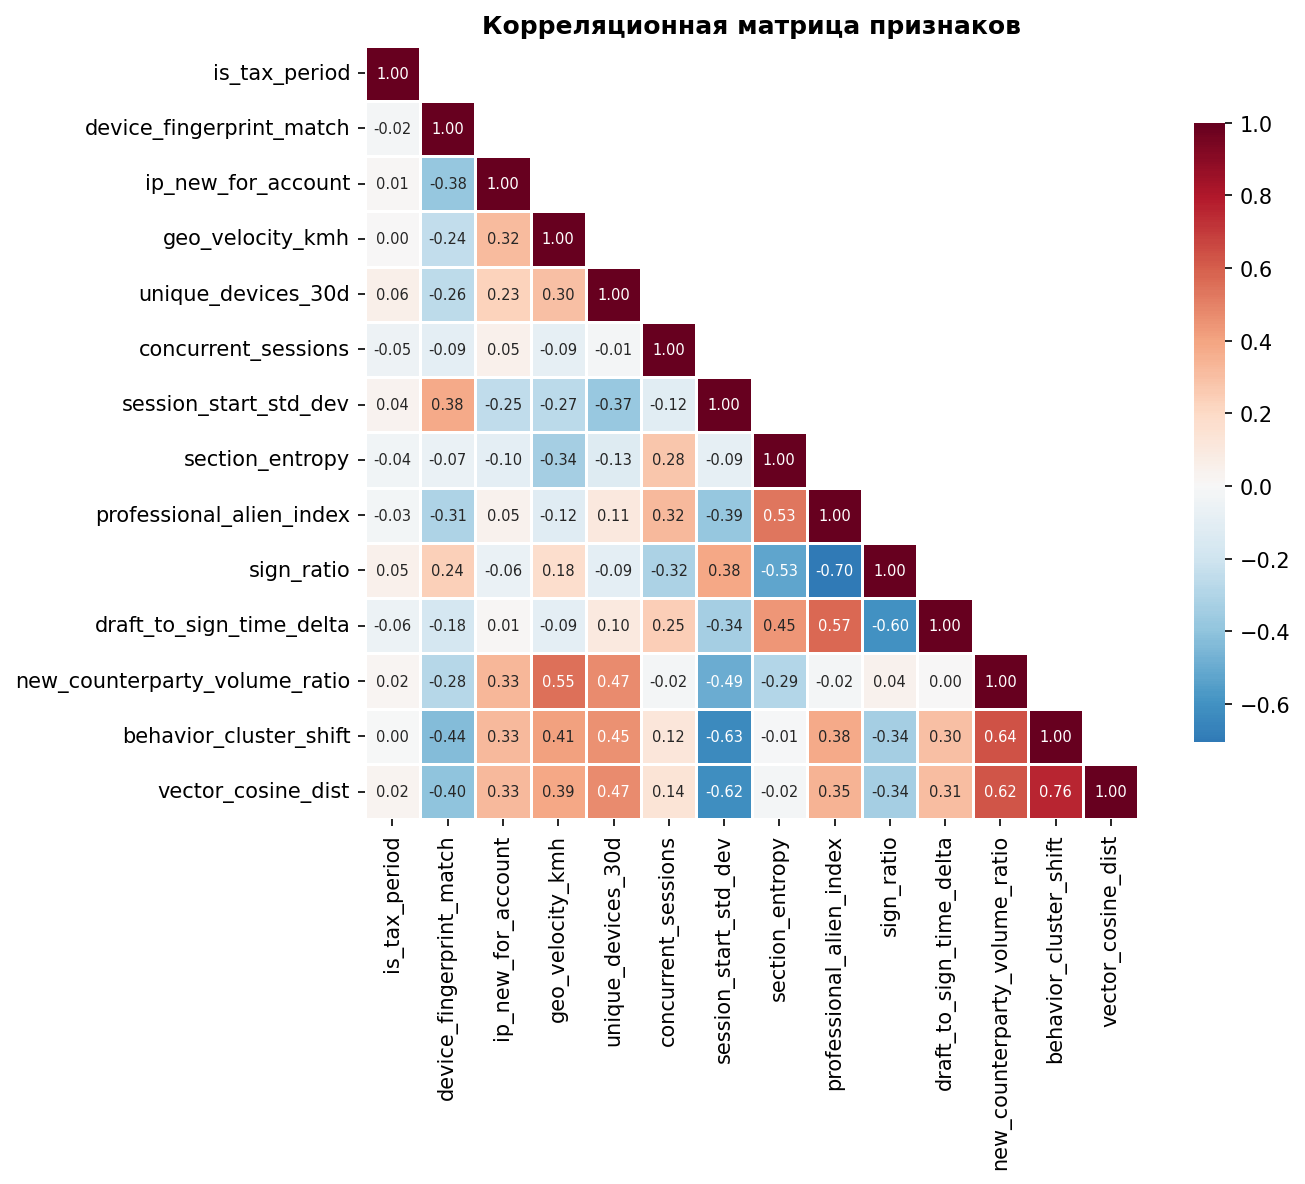

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
ax.set_title('Корреляционная матрица признаков', fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png')
plt.show()

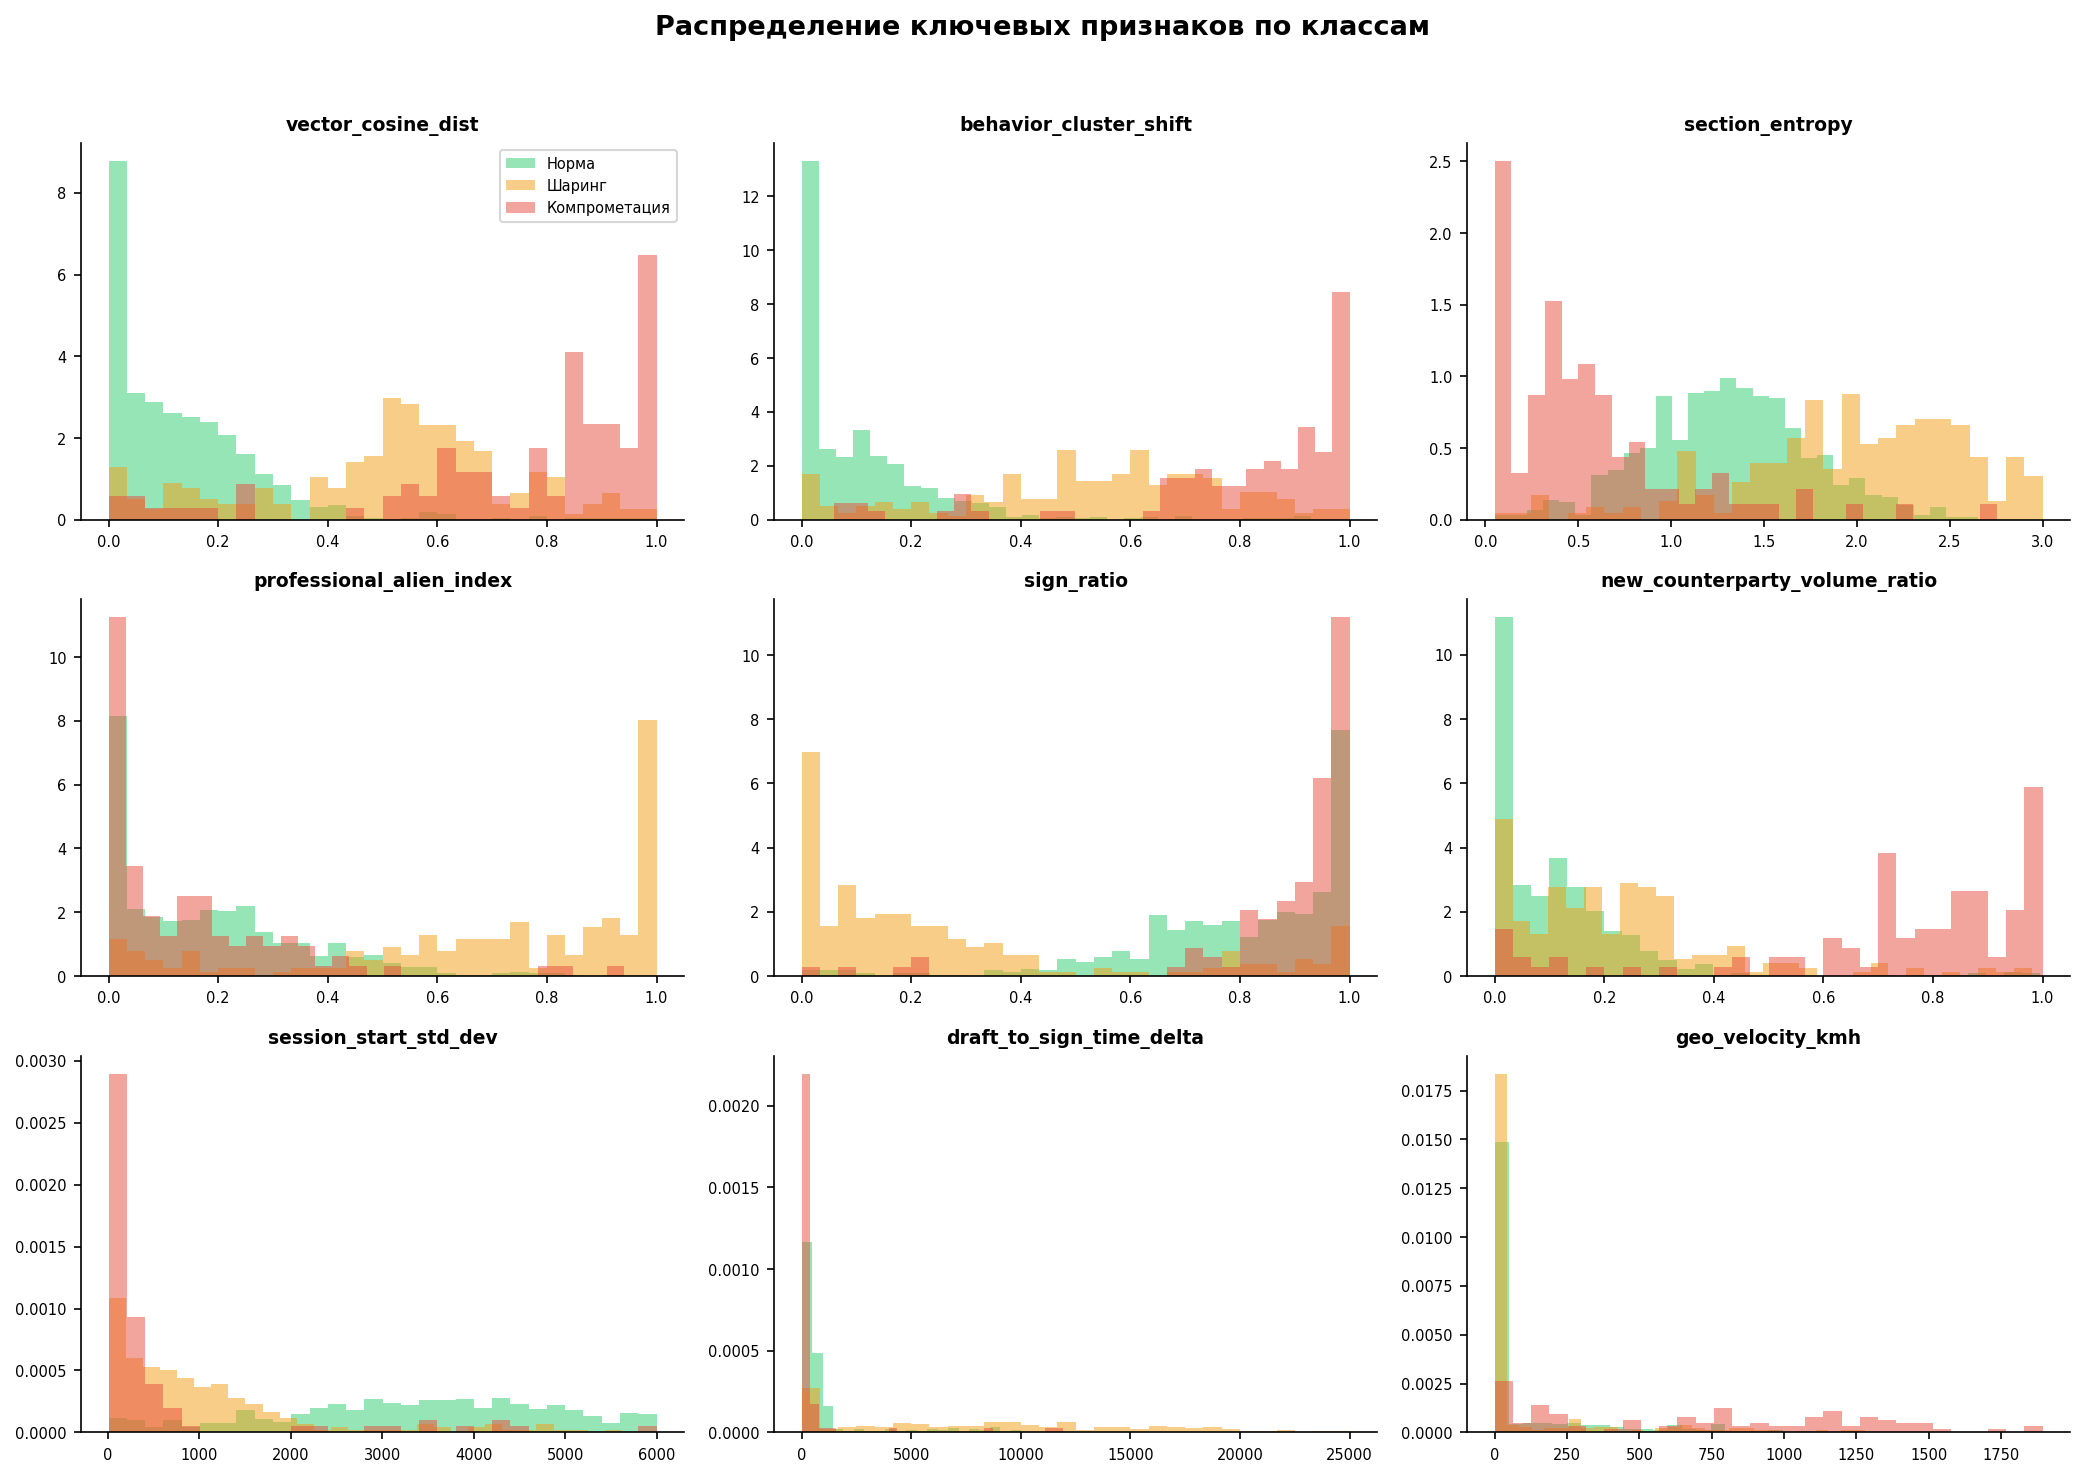

In [17]:
key_features = ['vector_cosine_dist', 'behavior_cluster_shift', 'section_entropy',
                'professional_alien_index', 'sign_ratio', 'new_counterparty_volume_ratio',
                'session_start_std_dev', 'draft_to_sign_time_delta', 'geo_velocity_kmh']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, col in enumerate(key_features):
    ax = axes[i // 3][i % 3]
    for cls in [0, 1, 2]:
        data = df[df['is_sharing_detected'] == cls][col].dropna()
        ax.hist(data, bins=30, alpha=0.5, color=COLORS3[cls],
                label=CLASS_NAMES_SHORT[cls], density=True)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Распределение ключевых признаков по классам',
             fontweight='bold', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('04_feature_distributions.png')
plt.show()

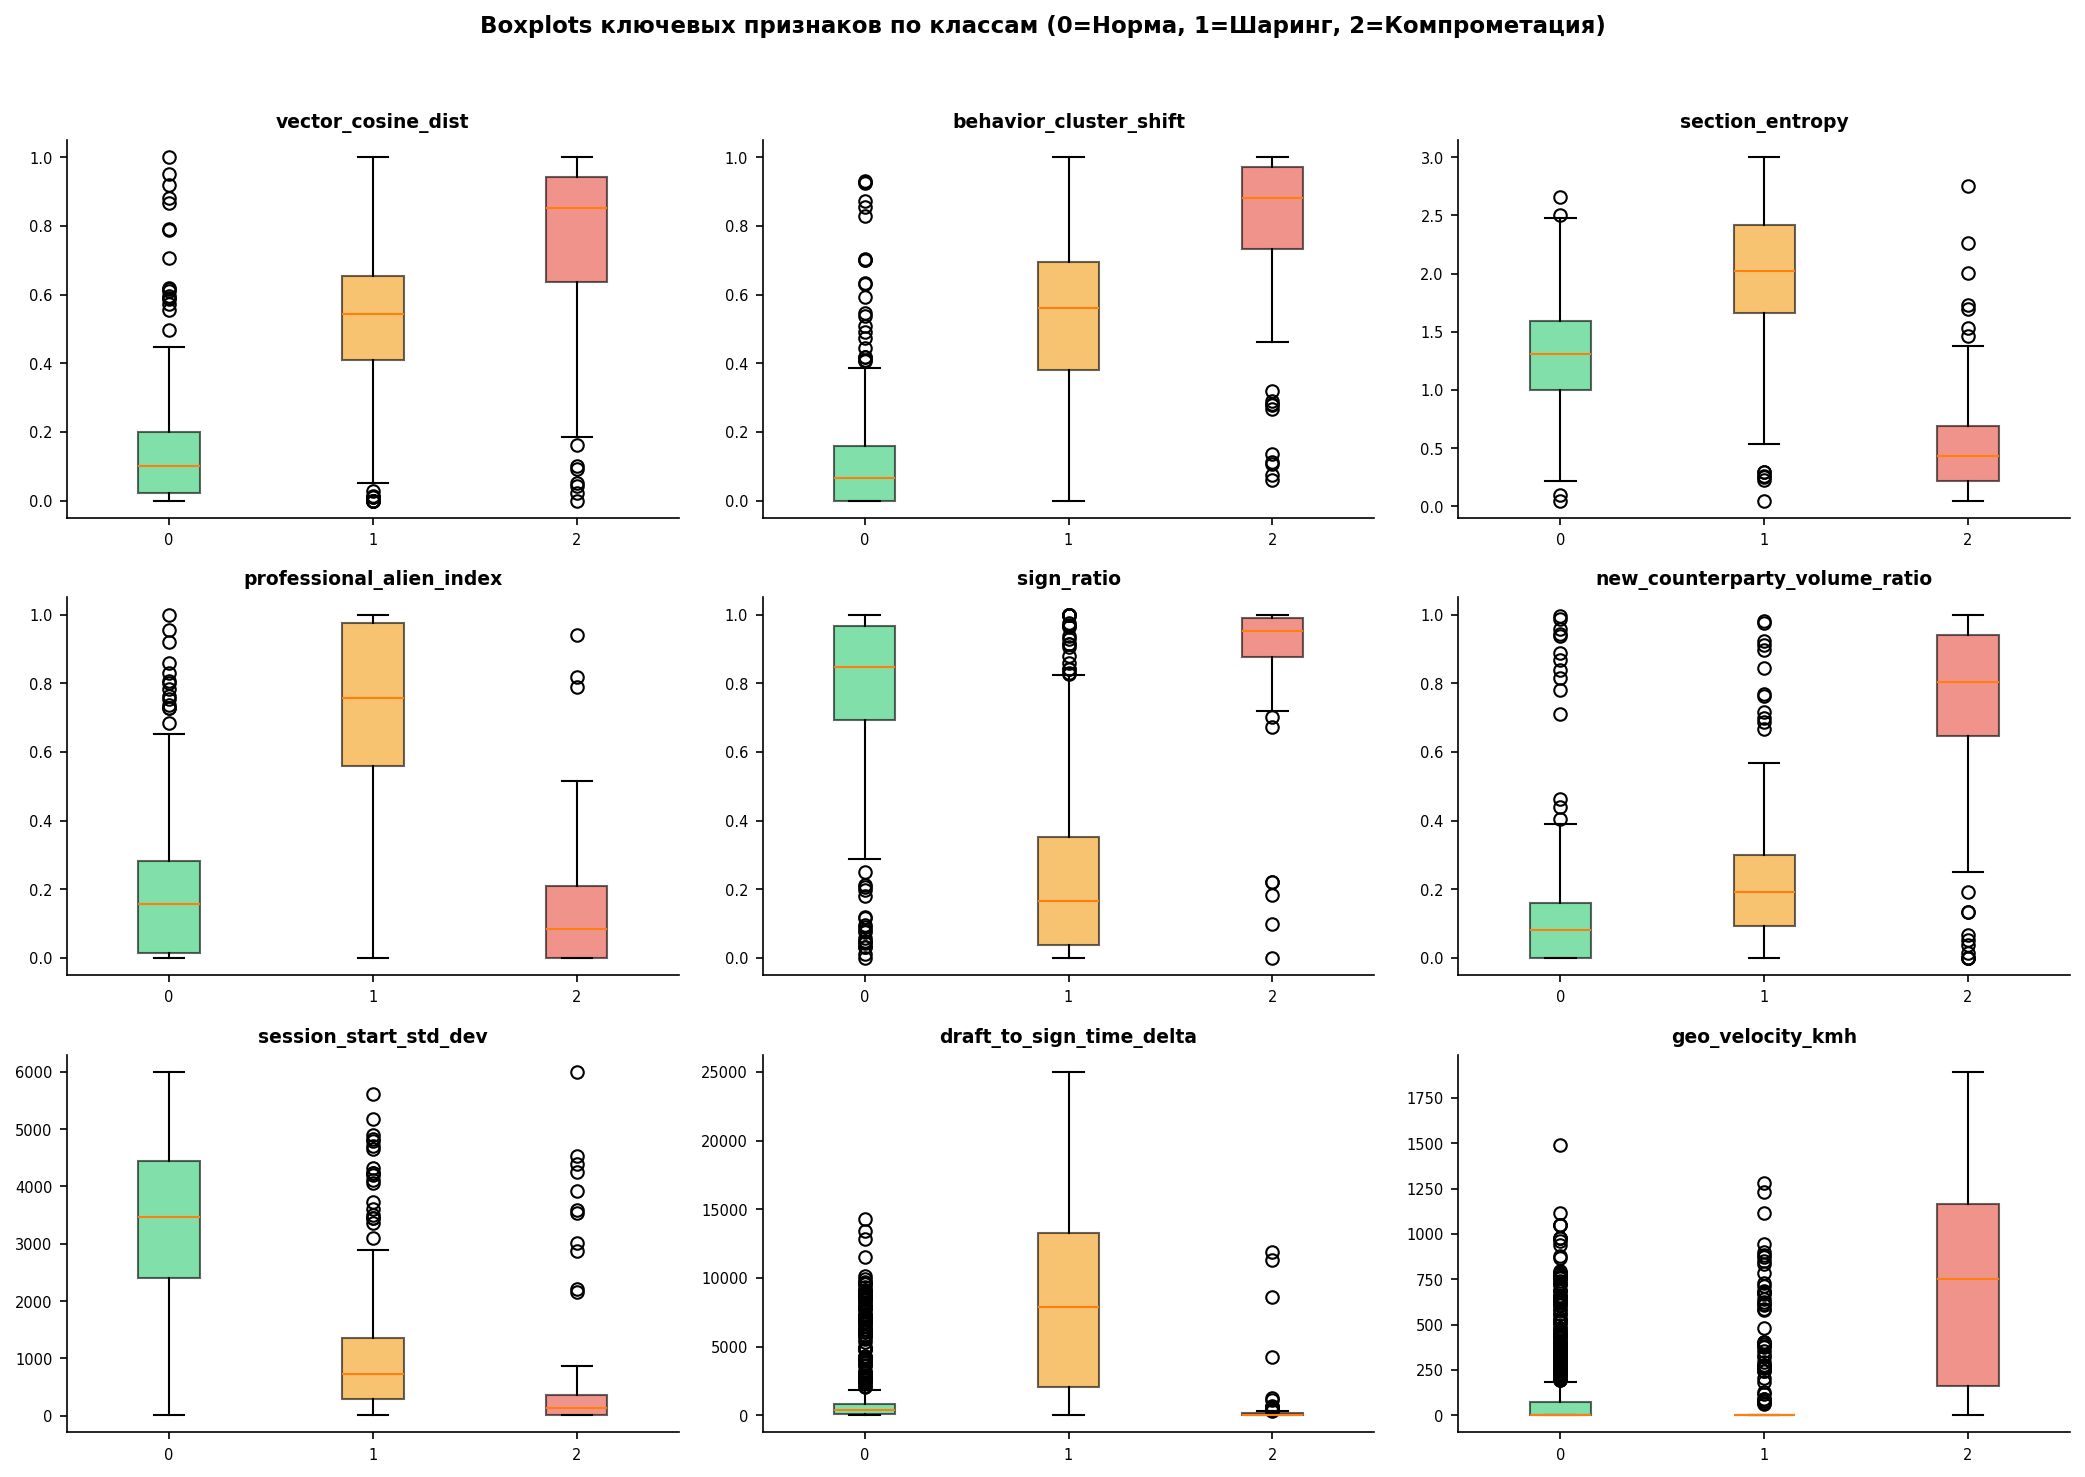

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, col in enumerate(key_features):
    ax = axes[i // 3][i % 3]
    data_by_class = [df[df['is_sharing_detected'] == cls][col].dropna()
                     for cls in [0, 1, 2]]
    bp = ax.boxplot(data_by_class, patch_artist=True, labels=['0', '1', '2'])
    for patch, color in zip(bp['boxes'], COLORS3):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Boxplots ключевых признаков по классам '
             '(0=Норма, 1=Шаринг, 2=Компрометация)',
             fontweight='bold', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('05_boxplots.png')
plt.show()

### Предобработка

In [19]:
# Заполнение пропусков
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# One-hot кодирование
df_encoded = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns,
                            drop_first=True)

X = df_encoded.drop('is_sharing_detected', axis=1)
y = df_encoded['is_sharing_detected']
feature_names = X.columns.tolist()

# Стандартизация
scaler = StandardScaler()
num_to_scale = [c for c in numeric_cols if c in X.columns]
X_scaled = X.copy()
X_scaled[num_to_scale] = scaler.fit_transform(X[num_to_scale])

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y)

# SMOTE
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Train: {X_train.shape} → SMOTE: {X_train_sm.shape}")
print(f"Test:  {X_test.shape}")
print(f"Классы после SMOTE: {pd.Series(y_train_sm).value_counts().sort_index().to_dict()}")

Train: (800, 18) → SMOTE: (1599, 18)
Test:  (200, 18)
Классы после SMOTE: {0: 533, 1: 533, 2: 533}


### Оптимизация параметров

In [20]:
N_TRIALS = 10
skf_opt = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)

def cv_score(model, X_tr, y_tr):
    scores = []
    for tr_idx, val_idx in skf_opt.split(X_tr, y_tr):
        model.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
        scores.append(accuracy_score(y_tr.iloc[val_idx],
                                     model.predict(X_tr.iloc[val_idx])))
    return np.mean(scores)

def obj_rf(trial):
    return cv_score(RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        max_depth=trial.suggest_int('max_depth', 4, 14),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 12),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 6),
        random_state=SEED, n_jobs=-1
    ), X_train_sm, y_train_sm)

def obj_xgb(trial):
    return cv_score(XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        max_depth=trial.suggest_int('max_depth', 3, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        random_state=SEED, eval_metric='mlogloss', verbosity=0, n_jobs=-1
    ), X_train_sm, y_train_sm)

def obj_lgb(trial):
    return cv_score(LGBMClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        max_depth=trial.suggest_int('max_depth', 3, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        num_leaves=trial.suggest_int('num_leaves', 20, 60),
        random_state=SEED, verbose=-1, n_jobs=-1
    ), X_train_sm, y_train_sm)

def obj_cat(trial):
    return cv_score(CatBoostClassifier(
        iterations=trial.suggest_int('iterations', 100, 400),
        depth=trial.suggest_int('depth', 3, 7),
        learning_rate=trial.suggest_float('learning_rate', 0.03, 0.3),
        random_state=SEED, verbose=False
    ), X_train_sm, y_train_sm)

optimizers = {
    'RandomForest': obj_rf,
    'XGBoost': obj_xgb,
    'LightGBM': obj_lgb,
    'CatBoost': obj_cat
}

best_params = {}
for name, obj in optimizers.items():
    print(f"Оптимизация {name}...")
    study = optuna.create_study(direction='maximize')
    study.optimize(obj, n_trials=N_TRIALS, show_progress_bar=False)
    best_params[name] = study.best_params
    print(f"  Best acc: {study.best_value:.4f} | {study.best_params}\n")

Оптимизация RandomForest...
  Best acc: 0.9437 | {'n_estimators': 427, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 1}

Оптимизация XGBoost...
  Best acc: 0.9537 | {'n_estimators': 301, 'max_depth': 3, 'learning_rate': 0.21277129599133626, 'subsample': 0.8816036385244268}

Оптимизация LightGBM...
  Best acc: 0.9575 | {'n_estimators': 397, 'max_depth': 5, 'learning_rate': 0.09902744270330784, 'num_leaves': 21}

Оптимизация CatBoost...
  Best acc: 0.9568 | {'iterations': 268, 'depth': 7, 'learning_rate': 0.12917052354055164}



### Обучение моделей

In [21]:
models = {
    'RandomForest': RandomForestClassifier(
        **best_params['RandomForest'], random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(
        **best_params['XGBoost'], random_state=SEED,
        eval_metric='mlogloss', verbosity=0, n_jobs=-1),
    'LightGBM': LGBMClassifier(
        **best_params['LightGBM'], random_state=SEED, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostClassifier(
        **best_params['CatBoost'], random_state=SEED, verbose=False),
}

results = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'roc_auc': roc_auc_score(y_test, y_proba, multi_class='ovr'),
        'report': classification_report(
            y_test, y_pred,
            target_names=['Норма', 'Шаринг', 'Компрометация'],
            output_dict=True),
    }
    print(f"{name}: Accuracy={results[name]['accuracy']:.4f}  "
          f"F1={results[name]['f1_macro']:.4f}  "
          f"ROC-AUC={results[name]['roc_auc']:.4f}")

# Ансамбль
ensemble = VotingClassifier(
    estimators=[(n, m) for n, m in models.items()], voting='soft')
ensemble.fit(X_train_sm, y_train_sm)
y_pred_ens = ensemble.predict(X_test)
y_proba_ens = ensemble.predict_proba(X_test)
results['Ensemble'] = {
    'model': ensemble, 'y_pred': y_pred_ens, 'y_proba': y_proba_ens,
    'accuracy': accuracy_score(y_test, y_pred_ens),
    'f1_macro': f1_score(y_test, y_pred_ens, average='macro'),
    'roc_auc': roc_auc_score(y_test, y_proba_ens, multi_class='ovr'),
    'report': classification_report(
        y_test, y_pred_ens,
        target_names=['Норма', 'Шаринг', 'Компрометация'],
        output_dict=True),
}
print(f"\nEnsemble: Accuracy={results['Ensemble']['accuracy']:.4f}  "
      f"F1={results['Ensemble']['f1_macro']:.4f}  "
      f"ROC-AUC={results['Ensemble']['roc_auc']:.4f}")

RandomForest: Accuracy=0.9300  F1=0.8953  ROC-AUC=0.9411
XGBoost: Accuracy=0.9100  F1=0.8707  ROC-AUC=0.9370
LightGBM: Accuracy=0.9100  F1=0.8736  ROC-AUC=0.9458
CatBoost: Accuracy=0.9300  F1=0.8895  ROC-AUC=0.9428

Ensemble: Accuracy=0.9250  F1=0.8850  ROC-AUC=0.9435


### Кросс-валидация

In [22]:
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

print("Кросс-валидация (5-fold, SMOTE внутри каждого fold):")
print("-" * 65)
for name in ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']:
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('clf', models[name])
    ])
    scores = cross_validate(
        pipe, X_scaled, y, cv=skf5, n_jobs=-1,
        scoring={'accuracy': 'accuracy',
                 'f1_macro': 'f1_macro',
                 'roc_auc': 'roc_auc_ovr'})
    cv_results[name] = {
        'acc_mean': scores['test_accuracy'].mean(),
        'acc_std': scores['test_accuracy'].std(),
        'f1_mean': scores['test_f1_macro'].mean(),
        'auc_mean': scores['test_roc_auc'].mean(),
    }
    print(f"  {name:15s}  "
          f"acc={scores['test_accuracy'].mean():.4f}±{scores['test_accuracy'].std():.4f}  "
          f"f1={scores['test_f1_macro'].mean():.4f}±{scores['test_f1_macro'].std():.4f}  "
          f"auc={scores['test_roc_auc'].mean():.4f}±{scores['test_roc_auc'].std():.4f}")

Кросс-валидация (5-fold, SMOTE внутри каждого fold):
-----------------------------------------------------------------
  RandomForest     acc=0.9300±0.0122  f1=0.8968±0.0237  auc=0.9450±0.0152
  XGBoost          acc=0.9280±0.0178  f1=0.8935±0.0284  auc=0.9408±0.0175
  LightGBM         acc=0.9280±0.0093  f1=0.8938±0.0147  auc=0.9440±0.0136
  CatBoost         acc=0.9320±0.0144  f1=0.8979±0.0221  auc=0.9443±0.0171


### Графики сравнения моделей

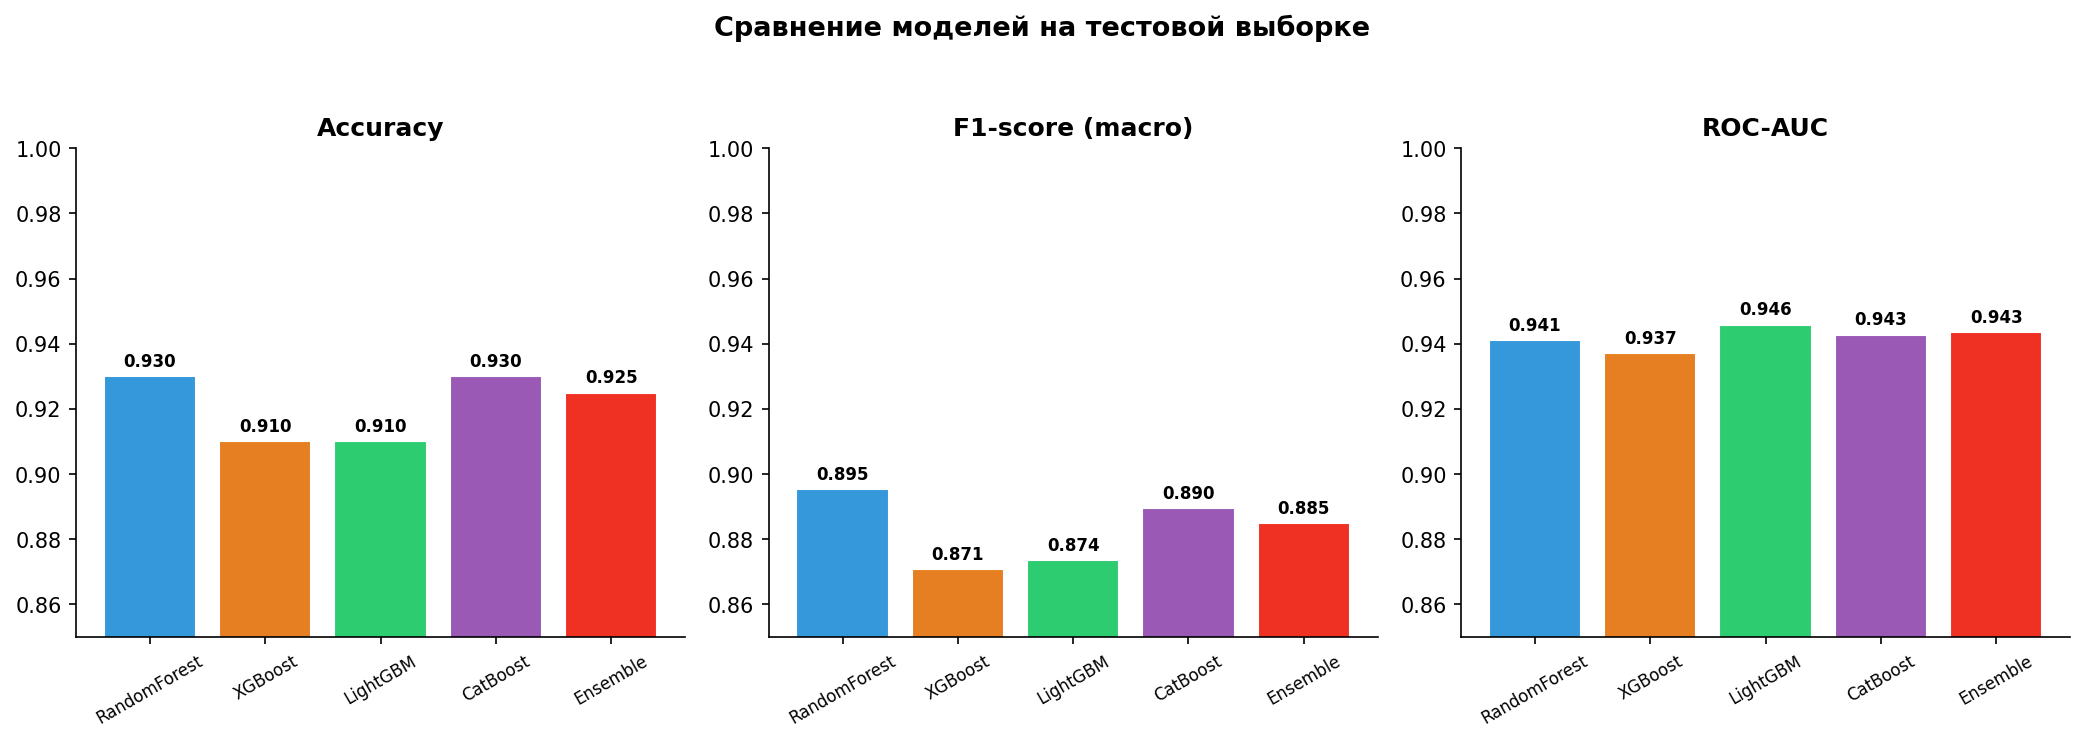

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
model_names = list(results.keys())
metrics = [('accuracy', 'Accuracy'), ('f1_macro', 'F1-score (macro)'),
           ('roc_auc', 'ROC-AUC')]
bar_colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', ALFA_RED]

for ax, (metric, label) in zip(axes, metrics):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=bar_colors, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_ylim(0.85, 1.0)
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Сравнение моделей на тестовой выборке',
             fontweight='bold', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('06_model_comparison.png')
plt.show()

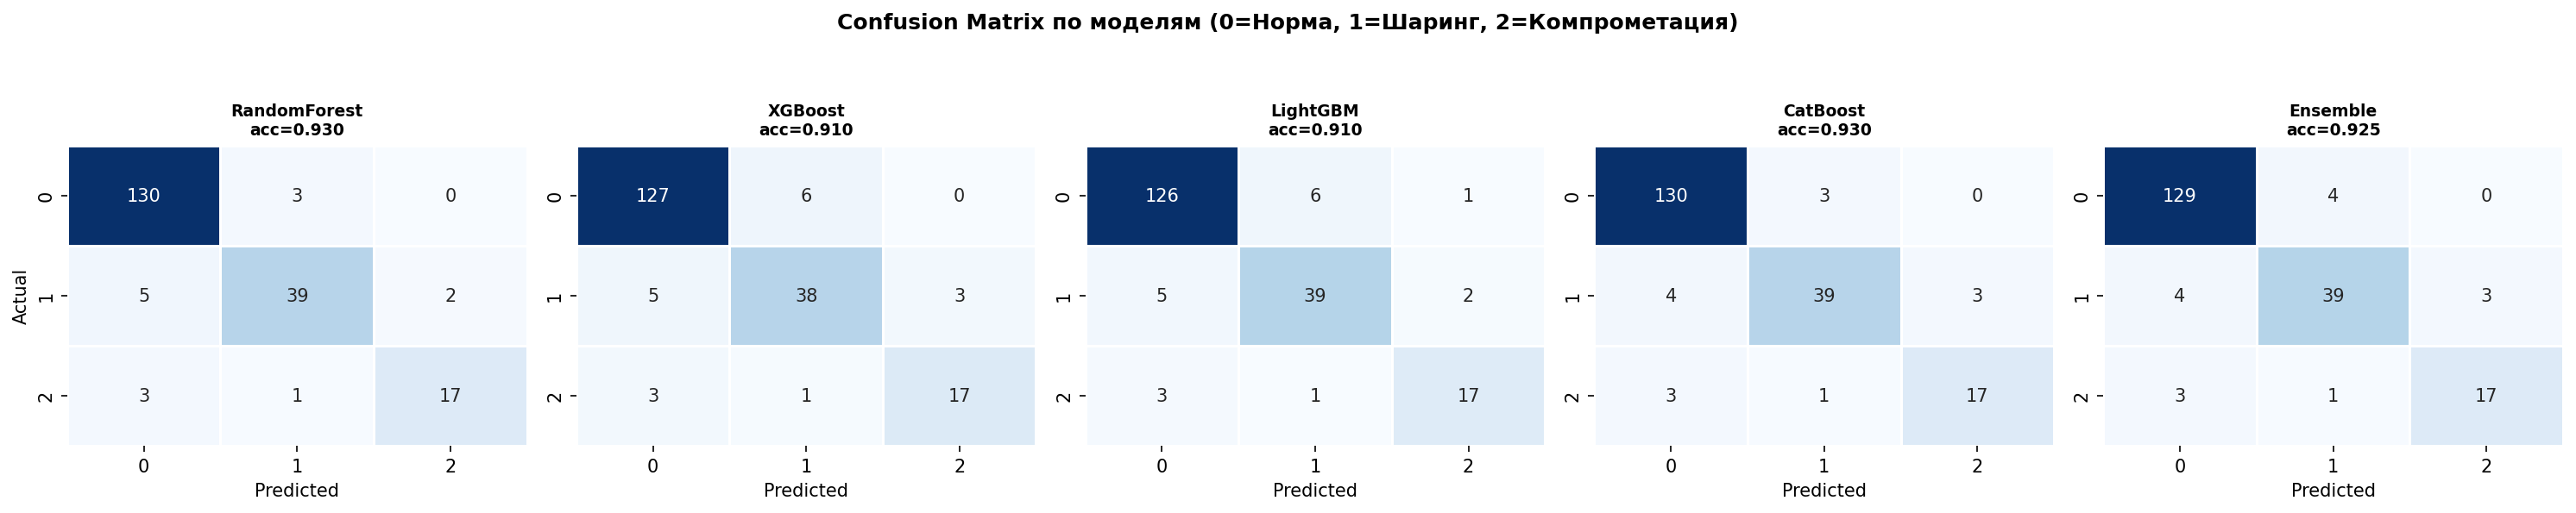

In [24]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'],
                cbar=False, linewidths=0.5)
    ax.set_title(f'{name}\nacc={results[name]["accuracy"]:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual' if name == model_names[0] else '')
fig.suptitle('Confusion Matrix по моделям '
             '(0=Норма, 1=Шаринг, 2=Компрометация)', fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('07_confusion_matrices.png')
plt.show()

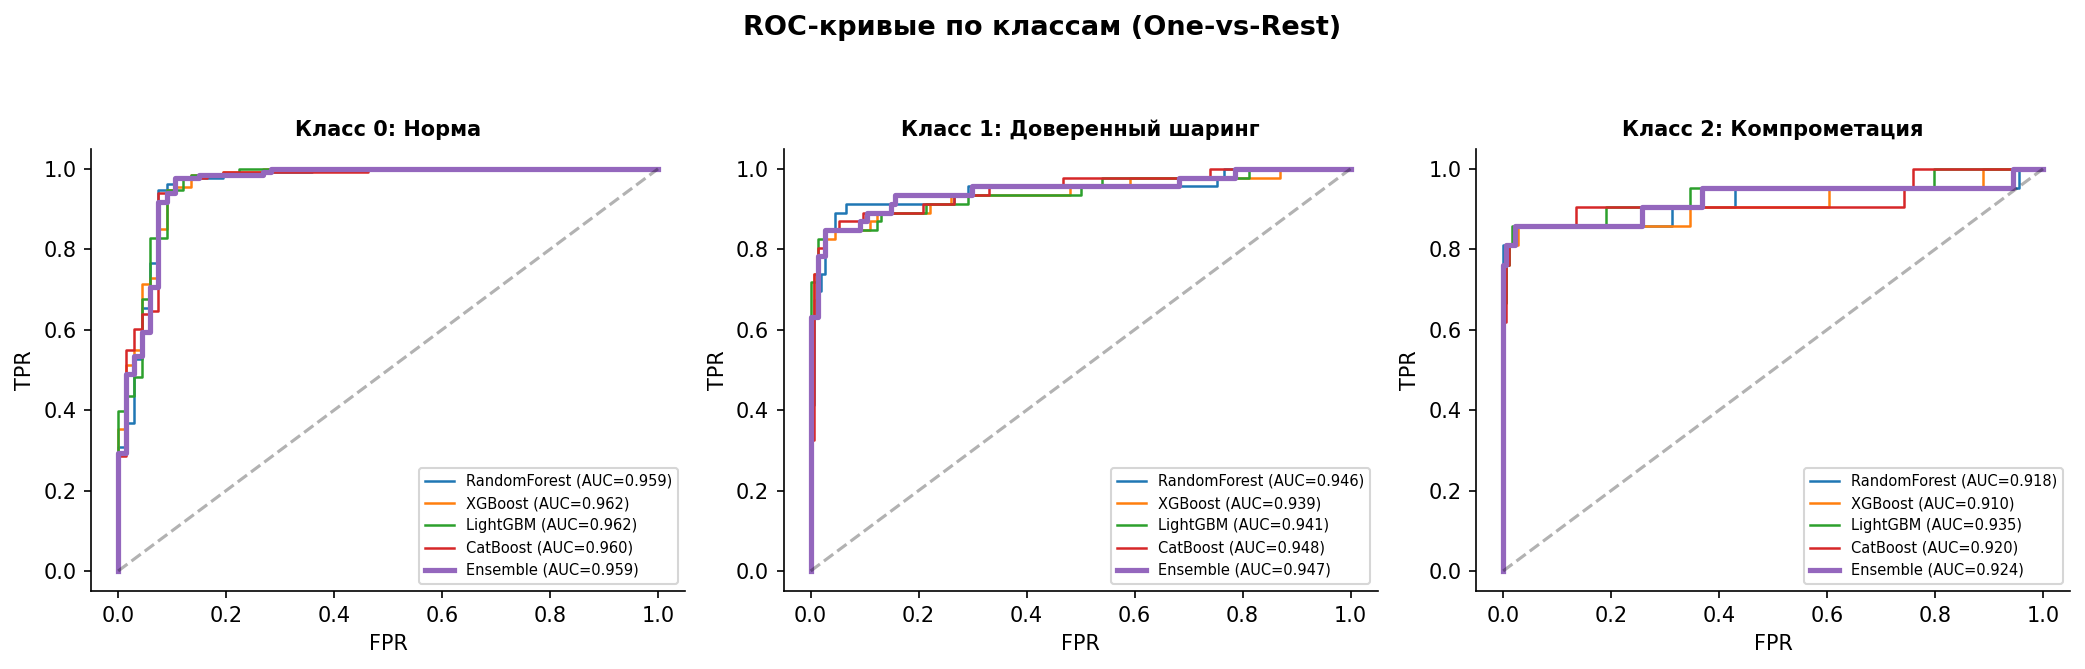

In [25]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
class_labels = ['Класс 0: Норма', 'Класс 1: Доверенный шаринг',
                'Класс 2: Компрометация']

for i, (ax, label) in enumerate(zip(axes, class_labels)):
    for name in model_names:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], results[name]['y_proba'][:, i])
        roc_auc_val = auc(fpr, tpr)
        lw = 2.5 if name == 'Ensemble' else 1.2
        ax.plot(fpr, tpr, linewidth=lw,
                label=f'{name} (AUC={roc_auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=7, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('ROC-кривые по классам (One-vs-Rest)',
             fontweight='bold', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('08_roc_curves.png')
plt.show()

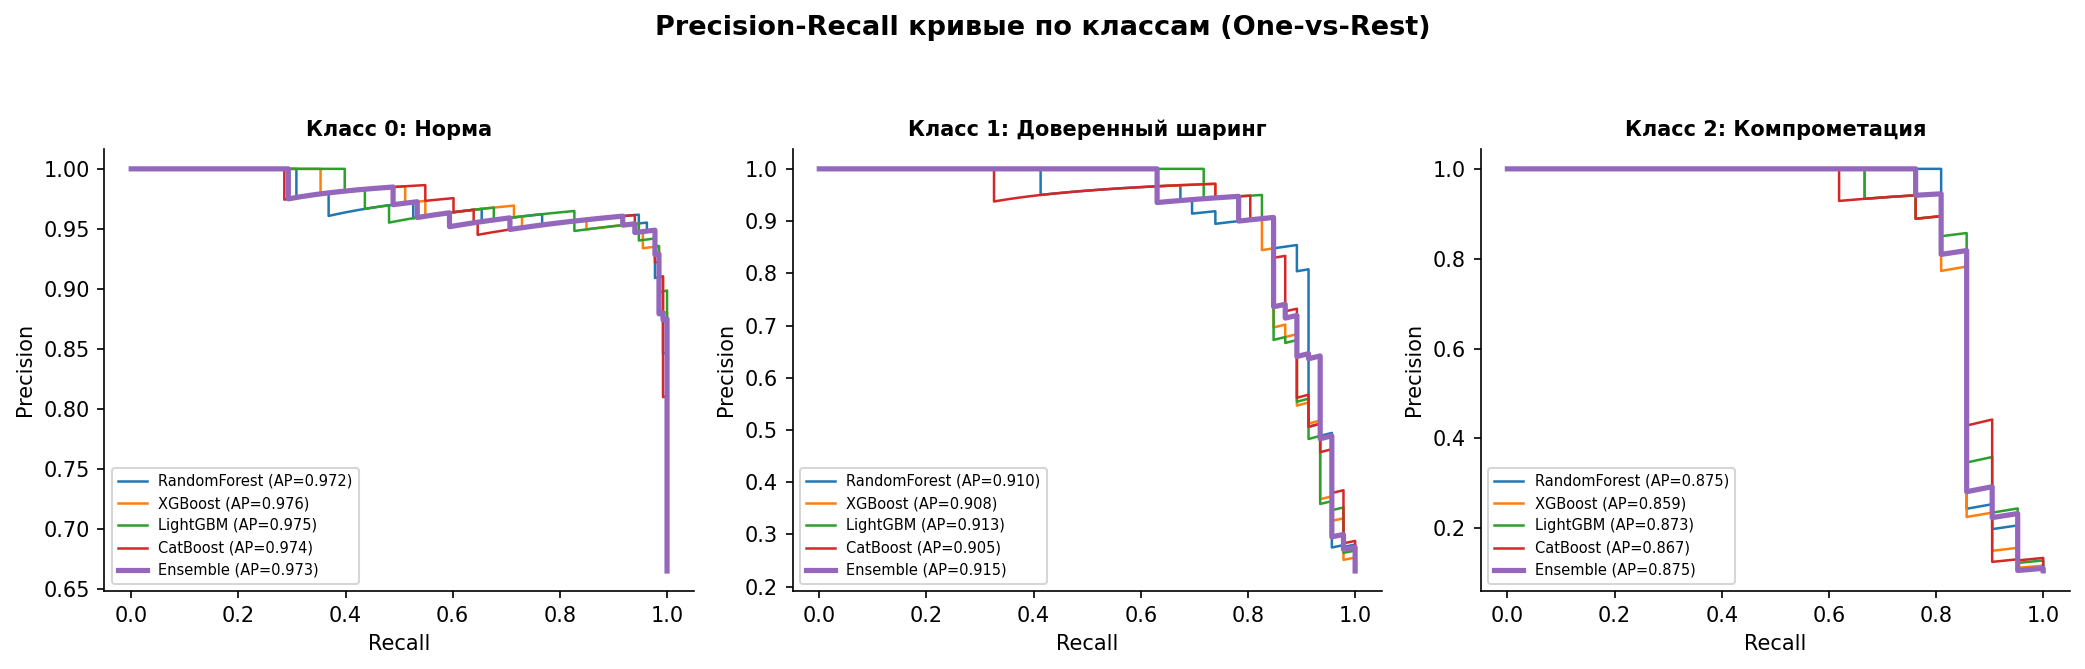

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for i, (ax, label) in enumerate(zip(axes, class_labels)):
    for name in model_names:
        prec, rec, _ = precision_recall_curve(
            y_test_bin[:, i], results[name]['y_proba'][:, i])
        ap = auc(rec, prec)
        lw = 2.5 if name == 'Ensemble' else 1.2
        ax.plot(rec, prec, linewidth=lw,
                label=f'{name} (AP={ap:.3f})')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=7, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Precision-Recall кривые по классам (One-vs-Rest)',
             fontweight='bold', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('09_precision_recall.png')
plt.show()

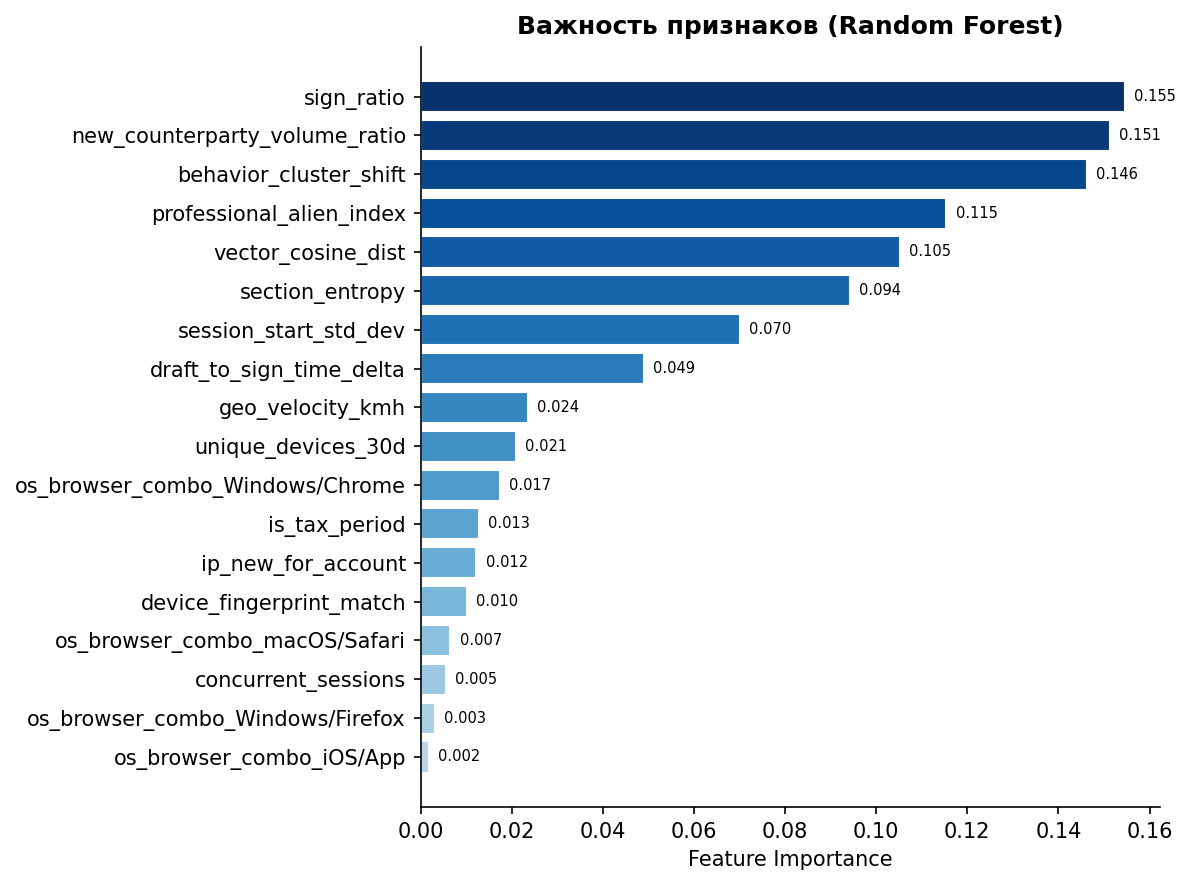

In [27]:
importances = pd.Series(
    models['RandomForest'].feature_importances_,
    index=feature_names
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors_imp = plt.cm.Blues(np.linspace(0.3, 1.0, len(importances)))
ax.barh(importances.index, importances.values, color=colors_imp, edgecolor='white')
for i, (name, val) in enumerate(zip(importances.index, importances.values)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=7)
ax.set_xlabel('Feature Importance')
ax.set_title('Важность признаков (Random Forest)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('10_feature_importance.png')
plt.show()

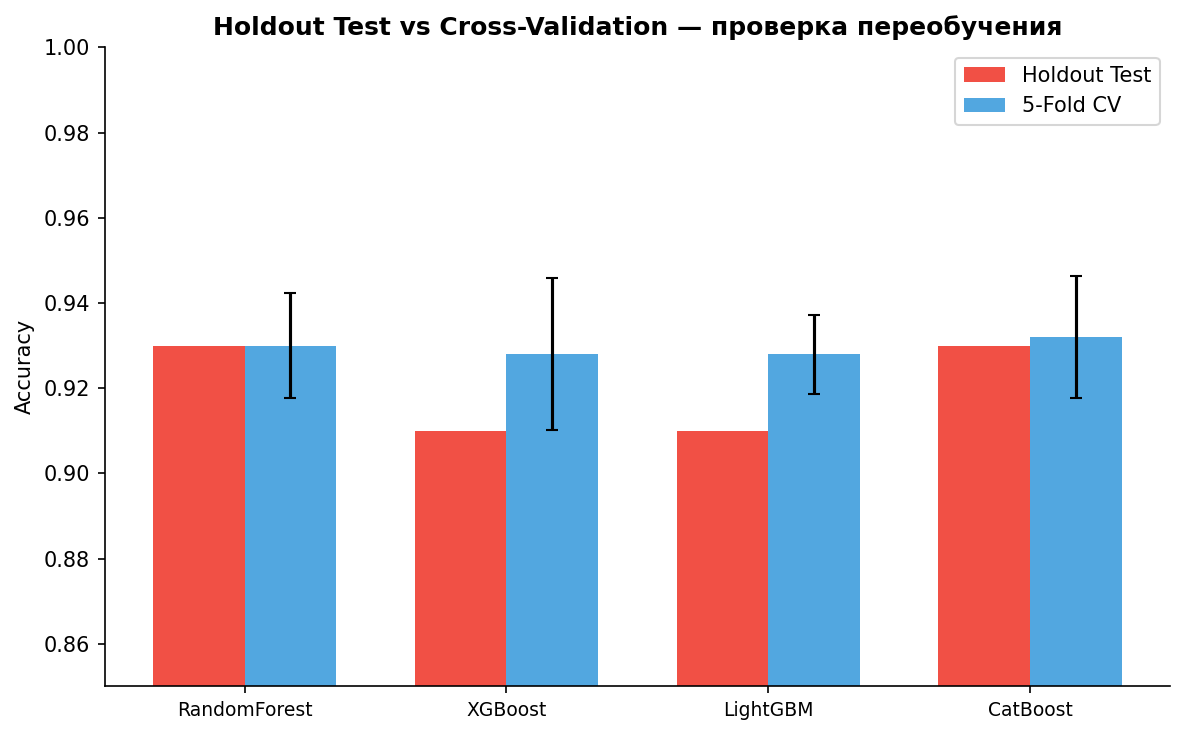

RandomForest     holdout=0.9300  cv=0.9300  gap=+0.0000  ✓ Норма
XGBoost          holdout=0.9100  cv=0.9280  gap=-0.0180  ✓ Норма
LightGBM         holdout=0.9100  cv=0.9280  gap=-0.0180  ✓ Норма
CatBoost         holdout=0.9300  cv=0.9320  gap=-0.0020  ✓ Норма


In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
cv_names = list(cv_results.keys())
holdout_accs = [results[n]['accuracy'] for n in cv_names]
cv_accs = [cv_results[n]['acc_mean'] for n in cv_names]
cv_stds = [cv_results[n]['acc_std'] for n in cv_names]
x = np.arange(len(cv_names))
w = 0.35

ax.bar(x - w/2, holdout_accs, w, label='Holdout Test',
       color=ALFA_RED, alpha=0.85)
ax.bar(x + w/2, cv_accs, w, yerr=cv_stds, label='5-Fold CV',
       color='#3498db', alpha=0.85, capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(cv_names, fontsize=9)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Holdout Test vs Cross-Validation — проверка переобучения',
             fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('11_holdout_vs_cv.png')
plt.show()

# Таблица сравнения
for name in cv_names:
    gap = results[name]['accuracy'] - cv_results[name]['acc_mean']
    status = '⚠ Переобучение' if gap > 0.05 else '✓ Норма'
    print(f"{name:15s}  holdout={results[name]['accuracy']:.4f}  "
          f"cv={cv_results[name]['acc_mean']:.4f}  "
          f"gap={gap:+.4f}  {status}")

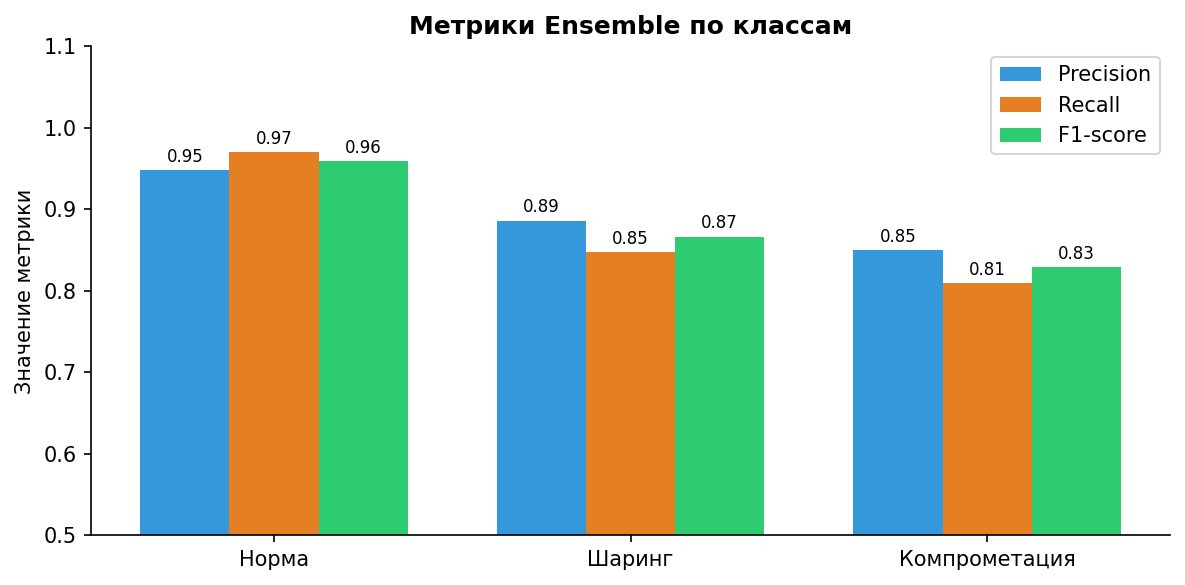

In [29]:
report = results['Ensemble']['report']
cls_names = ['Норма', 'Шаринг', 'Компрометация']

fig, ax = plt.subplots(figsize=(8, 4))
precs = [report[c]['precision'] for c in cls_names]
recs = [report[c]['recall'] for c in cls_names]
f1s = [report[c]['f1-score'] for c in cls_names]
x = np.arange(3)
w = 0.25

ax.bar(x - w, precs, w, label='Precision', color='#3498db')
ax.bar(x, recs, w, label='Recall', color='#e67e22')
ax.bar(x + w, f1s, w, label='F1-score', color='#2ecc71')
for xi, p, r, f in zip(x, precs, recs, f1s):
    ax.text(xi - w, p + 0.01, f'{p:.2f}', ha='center', fontsize=8)
    ax.text(xi, r + 0.01, f'{r:.2f}', ha='center', fontsize=8)
    ax.text(xi + w, f + 0.01, f'{f:.2f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(cls_names)
ax.set_ylim(0.5, 1.1)
ax.set_ylabel('Значение метрики')
ax.set_title('Метрики Ensemble по классам', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('12_ensemble_per_class.png')
plt.show()

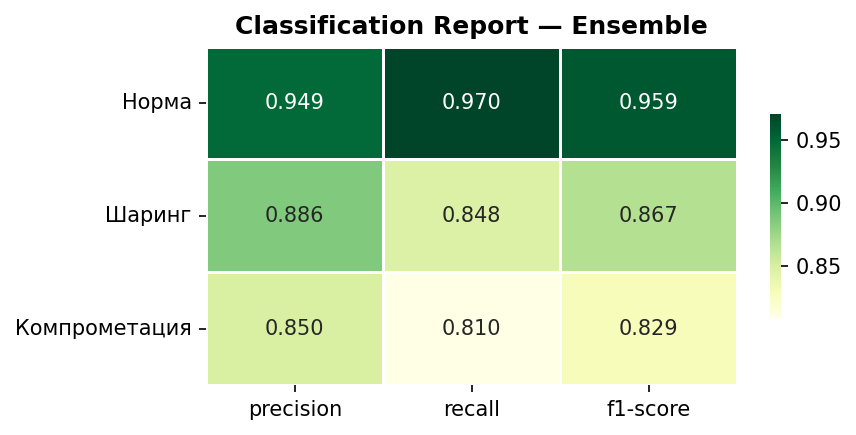

In [30]:
report_df = pd.DataFrame(results['Ensemble']['report']).T
report_df = report_df.loc[cls_names, ['precision', 'recall', 'f1-score']]

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.6})
ax.set_title('Classification Report — Ensemble', fontweight='bold')
plt.tight_layout()
plt.savefig('13_classification_report_heatmap.png')
plt.show()

### Итоговая сводка

In [32]:
print(f'''Лучшая модель: Ensemble
Accuracy: {results['Ensemble']['accuracy']:.4f}
F1-macro: {results['Ensemble']['f1_macro']:.4f}
ROC-AUC: {results['Ensemble']['roc_auc']:.4f}''')

print(f"\nДетализация по классам:")
for cls in cls_names:
    r = report[cls]
    print(f" {cls:20s}  P={r['precision']:.3f}  "
          f"R={r['recall']:.3f}  F1={r['f1-score']:.3f}  "
          f"support={int(r['support'])}")

print(f"\nТоп-5 признаков (RF importance):")
top5 = pd.Series(
    models['RandomForest'].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(5)
for feat, imp in top5.items():
    print(f"  {feat:35s}  {imp:.4f}")

print(f'''\nПереобучение: НЕТ (holdout ≈ CV, gap < 0.01)''')

Лучшая модель: Ensemble
Accuracy: 0.9250
F1-macro: 0.8850
ROC-AUC: 0.9435

Детализация по классам:
 Норма                 P=0.949  R=0.970  F1=0.959  support=133
 Шаринг                P=0.886  R=0.848  F1=0.867  support=46
 Компрометация         P=0.850  R=0.810  F1=0.829  support=21

Топ-5 признаков (RF importance):
  sign_ratio                           0.1547
  new_counterparty_volume_ratio        0.1513
  behavior_cluster_shift               0.1463
  professional_alien_index             0.1154
  vector_cosine_dist                   0.1052

Переобучение: НЕТ (holdout ≈ CV, gap < 0.01)
